In [5]:
# 1)  Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# To improve DataFrame Display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [6]:
# 2)  Loading the Dataset
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [7]:
# 3)  Lokking Into the Data
# Display the First Few Rows
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [6]:
# 4) Dataset Shape(Rows,Columns)
print("Matches Dataset shape:", matches.shape)
print("Deliveries Dataset shape:", deliveries.shape)

Matches Dataset shape: (1095, 20)
Deliveries Dataset shape: (260920, 17)


In [7]:
# 5) Dataset Information(Data Type and Nulls)
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [8]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [9]:
# Statistical Summary
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [10]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [11]:
# Checking Missing Values
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [12]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [13]:
# 8) Handling Missing Values- Matches Dataset
# Winner is missing for abondoned/no result matches
matches['winner'].fillna('No Result', inplace=True)
# city can be missing for some matches
matches['city'].fillna('Unknown', inplace=True)

C:\Users\avane\AppData\Local\Temp\ipykernel_17368\4165458061.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna('No Result', inplace=True)
C:\Users\avane\AppData\Local\Temp\ipykernel_17368\4165458061.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [14]:
# 9) Verifying Missing Values After Cleaning
matches.isnull().sum()

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [15]:
# 10) Data type Conversion
# Convert date column to datetime
matches['date'] = pd.to_datetime(matches['date'], dayfirst=True)

In [16]:
# 11) Standardize the Column names
matches.columns = matches.columns.str.lower().str.strip()
deliveries.columns = deliveries.columns.str.lower().str.strip()

In [17]:
# 12) Final Data Check
matches.head()
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   object        
 2   city             1095 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1095 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [18]:
deliveries.head()
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [19]:
# Feature Engineering
# Margin of Victory in runs(only applicable when result is 'runs')



# Margin of Victory in runs
matches['win_by_runs'] = np.where(
    matches['result'] == 'runs',
    matches['result_margin'],
    0
)

# Margin of Victory in wickets
matches['win_by_wickets'] = np.where(
    matches['result'] == 'wickets',
    matches['result_margin'],
    0
)

In [20]:
# Create a feature to identify abondoned or no-result
matches['is_no_result'] = matches['winner'] == 'No Result'

In [21]:
# Create a feature indicating whether the toss winner also won the match
matches['toss_winner_match_winner'] = (
    matches['toss_winner'] == matches['winner']
)

In [22]:
matches.sample(10)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,win_by_runs,win_by_wickets,is_no_result,toss_winner_match_winner
158,419149,2009/10,Delhi,2010-04-11,League,PP Chawla,Feroz Shah Kotla,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,Kings XI Punjab,wickets,7.0,112.0,20.0,N,NaN,BF Bowden,AM Saheba,0.0,7.0,False,False
746,1178426,2019,Mumbai,2019-05-02,League,JJ Bumrah,Wankhede Stadium,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,Mumbai Indians,tie,NaN,163.0,20.0,Y,NaN,CK Nandan,S Ravi,0.0,0.0,False,True
596,1082610,2017,Rajkot,2017-04-18,League,CH Gayle,Saurashtra Cricket Association Stadium,Gujarat Lions,Royal Challengers Bangalore,Gujarat Lions,field,Royal Challengers Bangalore,runs,21.0,214.0,20.0,N,NaN,S Ravi,VK Sharma,21.0,0.0,False,False
263,548322,2012,Pune,2012-04-14,League,JD Ryder,Subrata Roy Sahara Stadium,Pune Warriors,Chennai Super Kings,Chennai Super Kings,bat,Pune Warriors,wickets,7.0,156.0,20.0,N,NaN,Aleem Dar,BNJ Oxenford,0.0,7.0,False,False
558,980983,2016,Hyderabad,2016-05-12,League,CH Morris,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Delhi Daredevils,Delhi Daredevils,field,Delhi Daredevils,wickets,7.0,147.0,20.0,N,NaN,K Bharatan,M Erasmus,0.0,7.0,False,True
697,1175357,2019,Kolkata,2019-03-24,League,AD Russell,Eden Gardens,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,wickets,6.0,182.0,20.0,N,NaN,AK Chaudhary,CB Gaffaney,0.0,6.0,False,True
295,548356,2012,Bangalore,2012-05-06,League,AB de Villiers,M Chinnaswamy Stadium,Royal Challengers Bangalore,Deccan Chargers,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,5.0,182.0,20.0,N,NaN,HDPK Dharmasena,BNJ Oxenford,0.0,5.0,False,True
600,1082614,2017,Mumbai,2017-04-22,League,MJ McClenaghan,Wankhede Stadium,Mumbai Indians,Delhi Daredevils,Delhi Daredevils,field,Mumbai Indians,runs,14.0,143.0,20.0,N,NaN,A Nand Kishore,S Ravi,14.0,0.0,False,False
517,980901,2016,Mumbai,2016-04-09,League,AM Rahane,Wankhede Stadium,Mumbai Indians,Rising Pune Supergiants,Mumbai Indians,bat,Rising Pune Supergiants,wickets,9.0,122.0,20.0,N,NaN,HDPK Dharmasena,CK Nandan,0.0,9.0,False,False
676,1136601,2018,Kolkata,2018-05-09,League,Ishan Kishan,Eden Gardens,Mumbai Indians,Kolkata Knight Riders,Kolkata Knight Riders,field,Mumbai Indians,runs,102.0,211.0,20.0,N,NaN,KN Ananthapadmanabhan,AK Chaudhary,102.0,0.0,False,False


In [23]:
# Ball Level Feature Engineering
# Identify boundary balls(4s and 6s)
deliveries['is_boundary'] = deliveries['batsman_runs'].isin([4,6])
# Identify dot balls
deliveries['is_dot_ball'] = deliveries['total_runs'] == 0

In [24]:
# Identify Single, Double and Triple Runs
deliveries['is_single'] = deliveries['batsman_runs'] == 1
deliveries['is_double'] = deliveries['batsman_runs'] == 2
deliveries['is_triple'] = deliveries['batsman_runs'] == 3

In [25]:
# Identify Wicket deliveries
deliveries['is_wicket_ball'] = deliveries['is_wicket'] == 1

In [26]:
# Create over number(ball column typically stores the ball count like 0.1,0.2 etc)
deliveries['over'] = deliveries['ball'].astype(int)

In [28]:
# Check newly created columns
matches[['win_by_runs', 'win_by_wickets', 'is_no_result', 'toss_winner_match_winner']].head()

,win_by_runs,win_by_wickets,is_no_result,toss_winner_match_winner
0,140.0,0.0,False,False
1,33.0,0.0,False,True
2,0.0,9.0,False,False
3,0.0,5.0,False,False
4,0.0,5.0,False,False


In [29]:
deliveries[['is_boundary', 'is_dot_ball', 'is_wicket', 'over']].head()

,is_boundary,is_dot_ball,is_wicket,over
0,False,False,0,1
1,False,True,0,2
2,False,False,0,3
3,False,True,0,4
4,False,True,0,5


In [30]:
# Exploratory Data Analysis(EDA): Match level insights
# Matches played per season
matches_per_season = matches.groupby('season')['id'].count()
matches_per_season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64

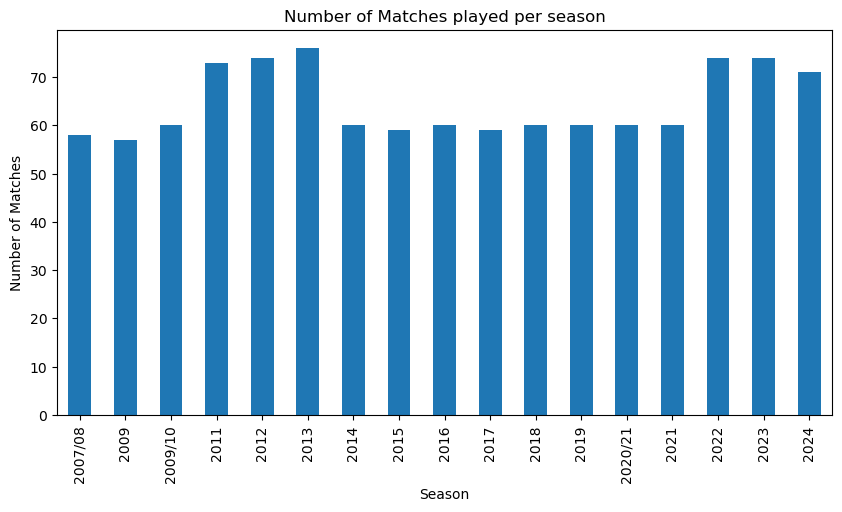

In [31]:
# Visualization
matches_per_season.plot(
    kind='bar',
    figsize=(10,5),
    title='Number of Matches played per season'
)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.show()

In [32]:
# Team wise total wins
team_wins = matches['winner'].value_counts()
team_wins.head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

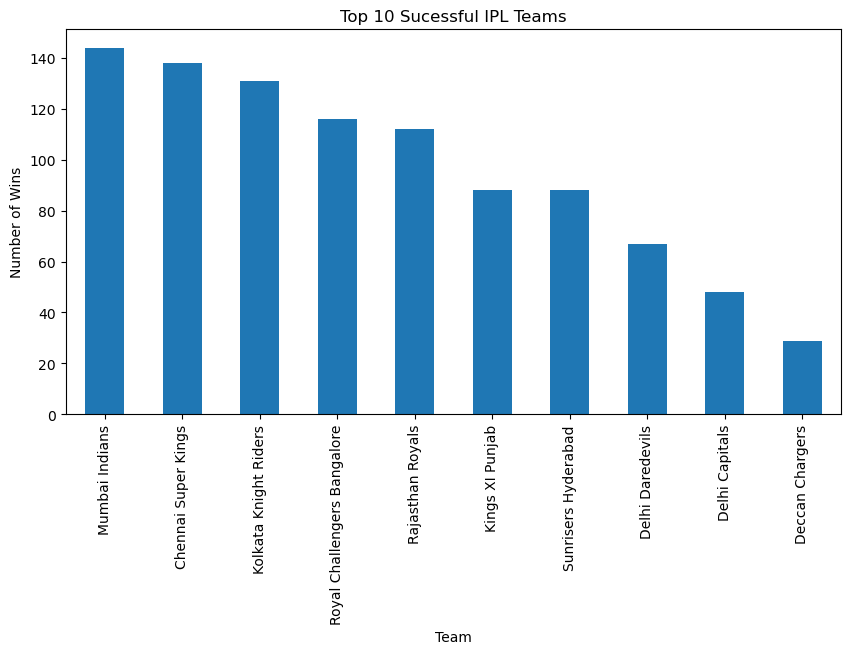

In [33]:
# Visualization
team_wins.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Sucessful IPL Teams'
)
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.show()

In [34]:
# Impact of Toss on Match Outcome
toss_match_win_count = matches['toss_winner_match_winner'].value_counts()
toss_match_win_count

toss_winner_match_winner
True     554
False    541
Name: count, dtype: int64

In [35]:
# Percentage Calculation
toss_win_percentage = (
    matches['toss_winner_match_winner'].mean() * 100
)
toss_win_percentage

np.float64(50.593607305936075)

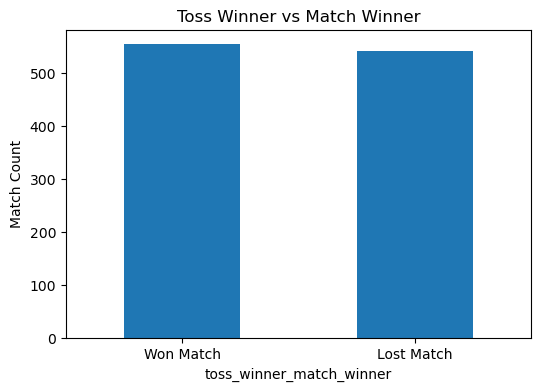

In [36]:
# Visualization
toss_match_win_count.plot(
    kind='bar',
    figsize=(6,4),
    title='Toss Winner vs Match Winner'
)
plt.xticks([0,1], ['Won Match', 'Lost Match'], rotation=0)
plt.ylabel('Match Count')
plt.show()           

In [37]:
# Match Result Type Analysis
result_type_counts = matches['result'].value_counts()
result_type_counts

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

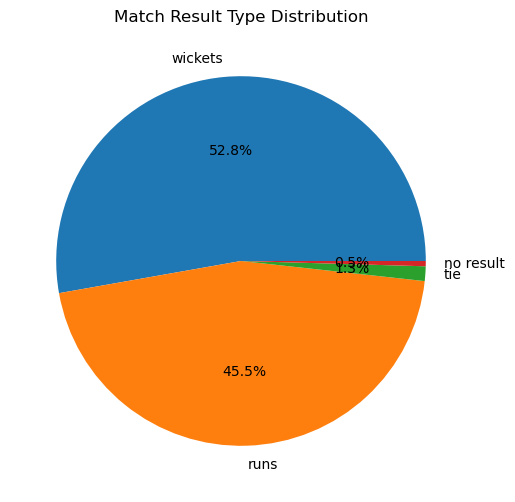

In [38]:
# Visualization
result_type_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    title='Match Result Type Distribution'
)
plt.ylabel('')
plt.show()

In [39]:
# No Result Matches
matches['is_no_result'].value_counts()

is_no_result
False    1090
True        5
Name: count, dtype: int64

In [40]:
# Season Wise Team Wins
season_team_wins = (
    matches
    .groupby(['season', 'winner'])
    .size()
    .unstack(fill_value=0)
)
season_team_wins

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Gujarat Titans,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,No Result,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad
season,,,,,,,,,,,,,,,,,,,,
2007/08,9,2,0,7,0,0,10,0,6,0,7,0,0,0,13,0,0,4,0,0
2009,8,9,0,10,0,0,7,0,3,0,5,0,0,0,6,0,0,9,0,0
2009/10,9,8,0,7,0,0,4,0,7,0,11,0,0,0,6,0,0,8,0,0
2011,11,6,0,4,0,0,7,6,8,0,10,1,4,0,6,0,0,10,0,0
2012,10,4,0,11,0,0,8,0,12,0,10,0,4,0,7,0,0,8,0,0
2013,12,0,0,3,0,0,8,0,6,0,13,0,4,0,11,0,0,9,0,10
2014,10,0,0,2,0,0,12,0,11,0,7,0,0,0,7,0,0,5,0,6
2015,10,0,0,5,0,0,3,0,7,0,10,2,0,0,7,0,0,8,0,7
2016,0,0,0,7,9,0,4,0,8,0,7,0,0,0,0,0,5,9,0,11


In [41]:
# Exploratory Data Analysis: Ball Level
# Top Batsman by Total Runs
top_batsman_runs = (
    deliveries
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
)
top_batsman_runs.head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

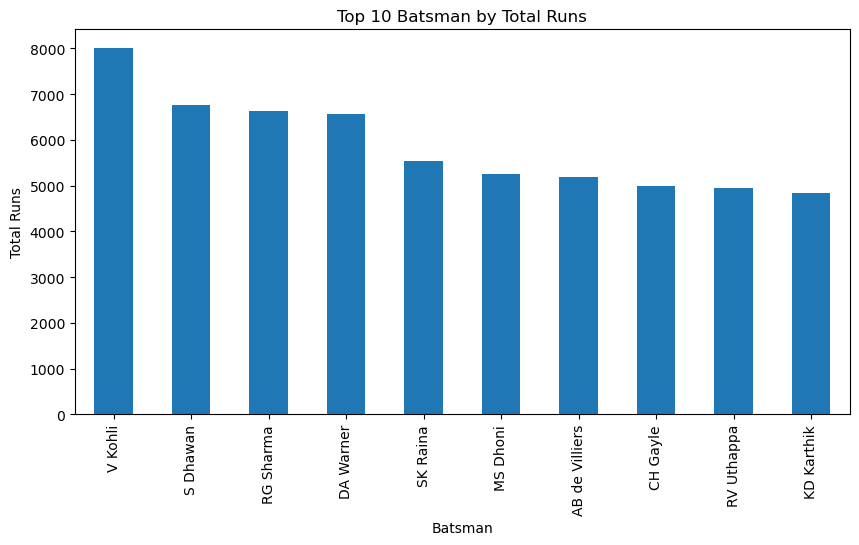

In [42]:
# Visualization
top_batsman_runs.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Batsman by Total Runs'
)
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.show()

In [43]:
# balls Faced by Batsman
balls_faced = deliveries.groupby('batter').size().sort_values(ascending=False)
balls_faced.head(10)

batter
V Kohli       6236
S Dhawan      5483
RG Sharma     5183
DA Warner     4849
SK Raina      4177
MS Dhoni      3947
RV Uthappa    3927
AM Rahane     3858
KD Karthik    3687
KL Rahul      3578
dtype: int64

In [44]:
# Strike rate Calculation
batsman_stats = deliveries.groupby('batter').agg(
    total_runs = ('batsman_runs', 'sum'),
    balls_faced = ('ball', 'count')
)
batsman_stats['strike_rate'] = (
    batsman_stats['total_runs'] / batsman_stats['balls_faced']
) * 100
batsman_stats.sort_values('strike_rate', ascending=False).head(10)

,total_runs,balls_faced,strike_rate
batter,,,
L Wood,9,3,300.000000
B Stanlake,5,2,250.000000
J Fraser-McGurk,330,150,220.000000
R Sai Kishore,13,6,216.666667
Umar Gul,39,19,205.263158
RS Sodhi,4,2,200.000000
Shahid Afridi,81,46,176.086957
I Malhotra,7,4,175.000000
WG Jacks,230,133,172.932331


In [45]:
# Boundary Count by Batsman
boundary_count = (
    deliveries[deliveries['is_boundary']]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)
boundary_count.head(10)

batter
V Kohli           981
S Dhawan          921
DA Warner         899
RG Sharma         880
CH Gayle          767
SK Raina          710
AB de Villiers    667
RV Uthappa        663
KD Karthik        627
MS Dhoni          615
dtype: int64

In [46]:
# Top Bowlers by Wickets
top_bowlers_wickets = (
    deliveries[deliveries['is_wicket_ball']]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
)
top_bowlers_wickets.head(10)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
dtype: int64

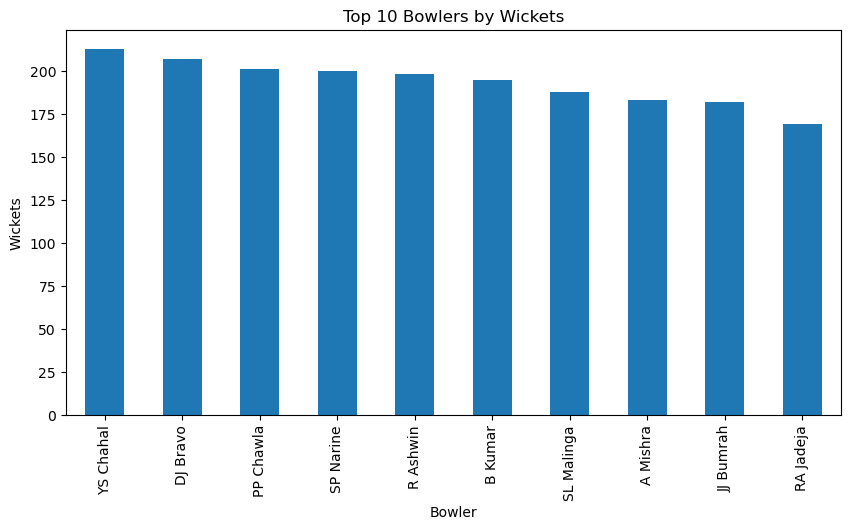

In [47]:
# Visualization
top_bowlers_wickets.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Bowlers by Wickets'
)
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.show()

In [48]:
# Economy rate Calculation
bowler_stats = deliveries.groupby('bowler').agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count')
)
bowler_stats['economy_rate'] = (
    bowler_stats['runs_conceded'] / bowler_stats['balls_bowled']
) * 6
bowler_stats.sort_values('economy_rate').head(10)

,runs_conceded,balls_bowled,economy_rate
bowler,,,
AC Gilchrist,0,1,0.000000
R Ravindra,7,12,3.500000
NB Singh,18,25,4.320000
Sachin Baby,8,10,4.800000
AM Rahane,5,6,5.000000
LA Carseldine,6,7,5.142857
SS Mundhe,6,7,5.142857
DJ Thornely,40,44,5.454545
M Manhas,42,42,6.000000


In [52]:
# Dot ball Percentage
dot_ball_stats = deliveries.groupby('bowler').agg(
    dot_balls=('is_dot_ball', 'sum'),
    total_balls=('ball', 'count')
)
dot_ball_stats['dot_ball_percentage'] = (
    dot_ball_stats['dot_balls'] / dot_ball_stats['total_balls']
) * 100
dot_ball_stats.sort_values('dot_ball_percentage', ascending=False).head(10)

,dot_balls,total_balls,dot_ball_percentage
bowler,,,
AC Gilchrist,1,1,100.000000
SS Iyer,4,6,66.666667
LA Carseldine,4,7,57.142857
SS Mundhe,4,7,57.142857
DJ Muthuswami,44,84,52.380952
NB Singh,13,25,52.000000
MP Yadav,39,76,51.315789
JW Hastings,31,61,50.819672
NJ Rimmington,9,18,50.000000


In [53]:
# Filters Batsman with Minimum  balls faced
batsman_stats_filtered = batsman_stats[batsman_stats['balls_faced'] >= 500]
batsman_stats_filtered.sort_values('strike_rate', ascending=False).head(10)

,total_runs,balls_faced,strike_rate
batter,,,
AD Russell,2488,1515,164.224422
H Klaasen,993,613,161.990212
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
LS Livingstone,939,609,154.187192
GJ Maxwell,2772,1842,150.488599
RM Patidar,799,534,149.625468
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059


In [54]:
# Merging Datasets & Advanced Insights
# Merge Match Level and Ball-Level Data
merged_df = deliveries.merge(
    matches[['id', 'season', 'winner', 'toss_decision']],
    left_on='match_id',
    right_on='id',
    how='left'
)
merged_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,is_boundary,is_dot_ball,is_single,is_double,is_triple,is_wicket_ball,id,season,winner,toss_decision
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,1,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,False,False,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,2,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,3,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,False,False,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,4,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,5,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,False,True,False,False,False,False,335982,2007/08,Kolkata Knight Riders,field


In [55]:
# Check merged dataset structure
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 27 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [56]:
# Average Runs Per Match By Season
season_runs = (
    merged_df
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
)
matches_per_season = matches.groupby('season')['id'].count().reset_index()

season_summary = season_runs.merge(
    matches_per_season,
    on='season'
)

season_summary['avg_runs_per_match'] = (
    season_summary['total_runs'] / season_summary['id']
)
season_summary

,season,total_runs,id,avg_runs_per_match
0,2007/08,17937,58,309.258621
1,2009,16353,57,286.894737
2,2009/10,18883,60,314.716667
3,2011,21154,73,289.780822
4,2012,22453,74,303.418919
5,2013,22602,76,297.394737
6,2014,18931,60,315.516667
7,2015,18353,59,311.067797
8,2016,18862,60,314.366667
9,2017,18786,59,318.406780


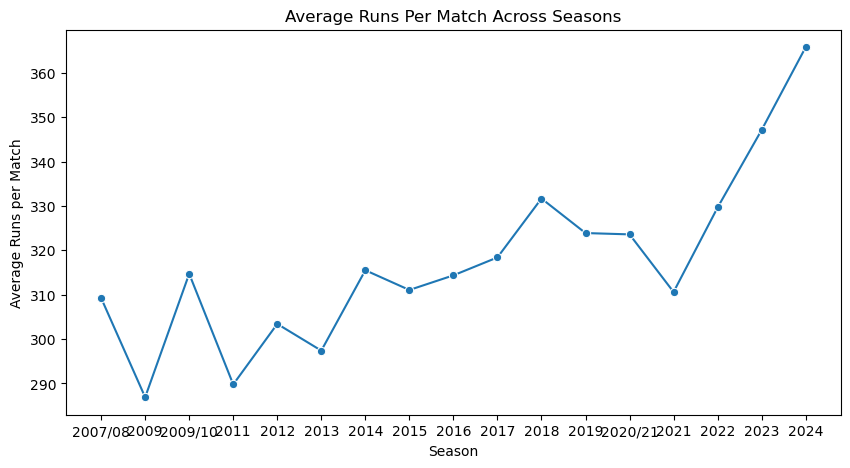

In [59]:
# Visualization Using Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=season_summary,
    x='season',
    y='avg_runs_per_match',
    marker='o'
)
plt.title('Average Runs Per Match Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Runs per Match')
plt.show()

In [61]:
# Runs Scored based on the Toss Decision
toss_runs = (
    merged_df
    .groupby('toss_decision')['total_runs']
    .sum()
    .reset_index()
)
toss_runs

,toss_decision,total_runs
0,bat,120447
1,field,227309


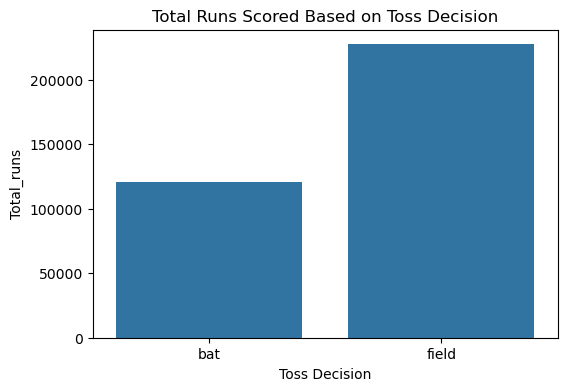

In [62]:
# Visualization
plt.figure(figsize=(6,4))
sns.barplot(
    data=toss_runs,
    x='toss_decision',
    y='total_runs'
)
plt.title('Total Runs Scored Based on Toss Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Total_runs')
plt.show()

In [69]:
# Top batsmen runs by season

top_batsmen = (
    merged_df
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

batsmen_season_runs = (
    merged_df[merged_df['batter'].isin(top_batsmen)]
    .groupby(['season', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

batsmen_season_runs.head()

,season,batter,batsman_runs
0,2007/08,RG Sharma,404
1,2007/08,S Dhawan,340
2,2007/08,SK Raina,421
3,2007/08,V Kohli,165
4,2009,DA Warner,163


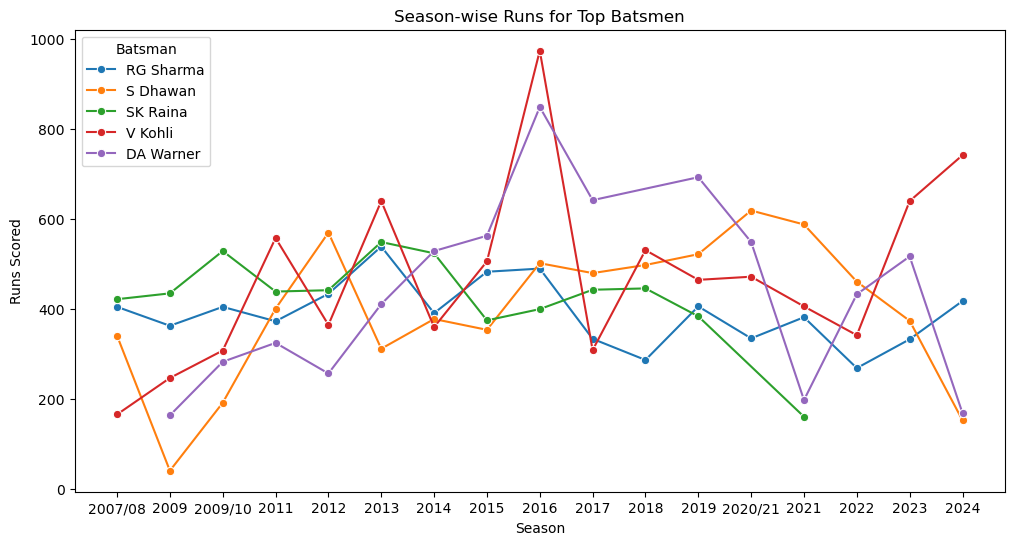

In [71]:
# Visualization
plt.figure(figsize=(12,6))
sns.lineplot(
    data=batsmen_season_runs,
    x='season',
    y='batsman_runs',
    hue='batter',
    marker='o'
)
plt.title('Season-wise Runs for Top Batsmen')
plt.xlabel('Season')
plt.ylabel('Runs Scored')
plt.legend(title='Batsman')
plt.show()

In [72]:
# Runs Scored by Winning Matches
winning_team_runs = (
    merged_df[merged_df['batting_team'] == merged_df['winner']]
    .groupby('winner')['total_runs']
    .sum()
    .sort_values(ascending=False)
)
winning_team_runs.head(10)

winner
Mumbai Indians                 24187
Chennai Super Kings            23337
Kolkata Knight Riders          20978
Royal Challengers Bangalore    19256
Rajasthan Royals               18880
Sunrisers Hyderabad            14518
Kings XI Punjab                14506
Delhi Daredevils               10837
Delhi Capitals                  8294
Gujarat Titans                  4916
Name: total_runs, dtype: int64

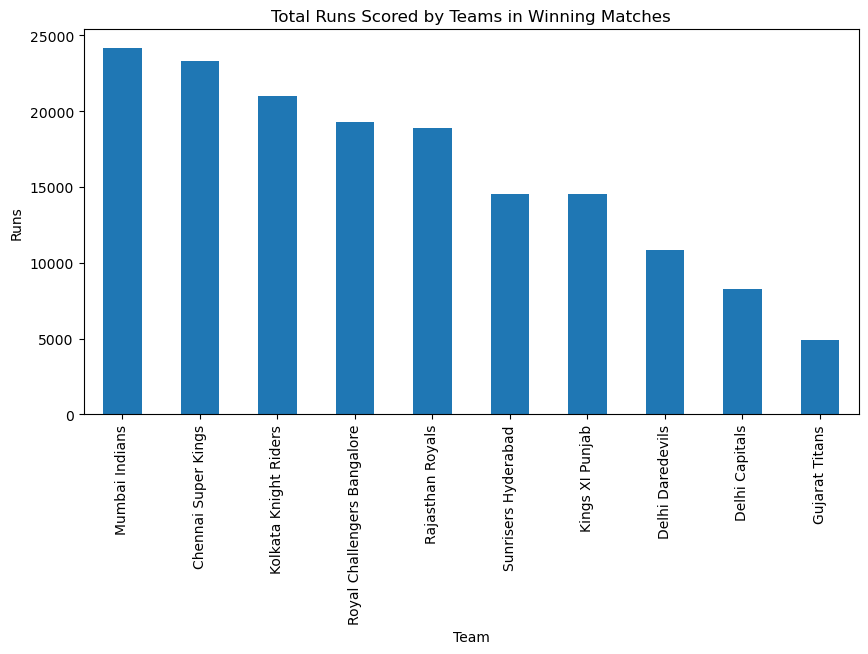

In [74]:
# Visualization
plt.figure(figsize=(10,5))
winning_team_runs.head(10).plot(kind='bar')
plt.title('Total Runs Scored by Teams in Winning Matches')
plt.xlabel('Team')
plt.ylabel('Runs')
plt.show()

In [2]:
# Geographical Analysis
# install folium if required
#!pip install folium
import folium


In [78]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [79]:
!pip --version

pip 25.3 from C:\ProgramData\anaconda3\Lib\site-packages\pip (python 3.13)



In [80]:
import sys
!{sys.executable} -m pip show folium

Name: folium
Version: 0.20.0
Summary: Make beautiful maps with Leaflet.js & Python
Home-page: https://github.com/python-visualization/folium
Author: Rob Story
Author-email: wrobstory@gmail.com
License: MIT
Location: C:\Users\avane\AppData\Roaming\Python\Python313\site-packages
Requires: branca, jinja2, numpy, requests, xyzservices
Required-by: 


In [81]:
import sys
!{sys.executable} -m pip install --force-reinstall folium

Defaulting to user installation because normal site-packages is not writeable
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.4 MB 7.9 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.4 MB 9.8 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.4 MB 13.2 MB/s eta 0:00:01
   ------------------------------------- -- 11.8/12.4 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 13.9 MB/s  0:00:00

   --- ------------------------------------  1/11 [urllib3]
   --- ------------------------------------  1/11 [urllib3]
   --- ------------------------------------  1/11 [urllib3]
   --- ------------------------------------  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.1 which is incompatible.


In [1]:
import folium
print(folium.__version__)

0.20.0


In [8]:
# Matches Played per city
city_matches = (
    matches
    .groupby('city')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'match_count'})
)

city_matches = city_matches[city_matches['city'] != 'Unknown']

city_matches.head()

,city,match_count
0,Abu Dhabi,37
1,Ahmedabad,36
2,Bangalore,65
3,Bengaluru,29
4,Bloemfontein,2


In [9]:
# City Coordinates Mapping
city_coordinates = {
    'Mumbai': [19.0760, 72.8777],
    'Delhi': [28.7041, 77.1025],
    'Bangalore': [12.9716, 77.5946],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Hyderabad': [17.3850, 78.4867],
    'Pune': [18.5204, 73.8567],
    'Jaipur': [26.9124, 75.7873],
    'Ahmedabad': [23.0225, 72.5714],
    'Chandigarh': [30.7333, 76.7794],
    'Indore': [22.7196, 75.8577],
    'Nagpur': [21.1458, 79.0882],
    'Dharamsala': [32.2190, 76.3234],
    'Visakhapatnam': [17.6868, 83.2185],
    'Raipur': [21.2514, 81.6296],
    'Ranchi': [23.3441, 85.3096]
}

In [10]:
# Map coordinates to city data
city_matches['coordinates'] = city_matches['city'].map(city_coordinates)

# Drop cities without coordinates
city_matches = city_matches.dropna(subset=['coordinates'])

city_matches.head()

,city,match_count,coordinates
1,Ahmedabad,36,"[23.0225, 72.5714]"
2,Bangalore,65,"[12.9716, 77.5946]"
7,Chandigarh,61,"[30.7333, 76.7794]"
8,Chennai,85,"[13.0827, 80.2707]"
10,Delhi,90,"[28.7041, 77.1025]"


In [12]:
# Create Base Map Centered on India
india_map = folium.Map(
    location=[22.5937, 78.9629],
    zoom_start=5,
    titles='OpenStreetMap'
)

In [14]:
# Add Markers For Each City
for _, row in city_matches.iterrows():
    folium.CircleMarker(
        location=row['coordinates'],
        radius=row['match_count'] / 5,
        popup=f"{row['city']}<br>Matches: {row['match_count']}",
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.7
    ).add_to(india_map)    

In [16]:
india_map